# AI-Ready Score - Phase 1 + Phase 2 Starter

This notebook completes the **data profiling engine** and adds a reusable **quality-check layer**.

Flow:

1. Load one or more CSV files.
2. Infer ML-oriented column types.
3. Build a structured data profile.
4. Infer/accept a target column and ML task type.
5. Run quality checks that return severity, explanation, and recommendation.
6. Compute a basic readiness score as a Phase 3 starting point.

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

## 1. Core profiler and quality-check functions

Keep these functions together for now. Later, move them into separate files such as `profiler.py`, `checks.py`, and `scoring.py`.

In [7]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd


def load_csv_files(
    folder_path: str | Path,
    pattern: str = "*.csv",
    add_source_file: bool = False,
    **read_csv_kwargs: Any,
) -> pd.DataFrame:
    """Load one or more CSV files from a folder and concatenate them."""
    folder = Path(folder_path)
    csv_files = sorted(folder.glob(pattern))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {folder.resolve()} with pattern {pattern!r}")

    frames: List[pd.DataFrame] = []
    for file_path in csv_files:
        part = pd.read_csv(file_path, **read_csv_kwargs)
        if add_source_file:
            part["_source_file"] = file_path.name
        frames.append(part)

    return pd.concat(frames, ignore_index=True, sort=False)


def _series_with_blank_as_na(series: pd.Series) -> pd.Series:
    """Return a copy where blank strings are treated as missing values."""
    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        return series.replace(r"^\s*$", np.nan, regex=True)
    return series


def _safe_sample(non_null: pd.Series, n: int = 5000) -> pd.Series:
    if len(non_null) <= n:
        return non_null
    return non_null.sample(n=n, random_state=42)


def _try_to_datetime(values: pd.Series) -> Tuple[pd.Series, float]:
    """Parse dates while staying compatible with different pandas versions."""
    sample = values.astype(str)
    try:
        parsed = pd.to_datetime(sample, errors="coerce", format="mixed")
    except TypeError:
        parsed = pd.to_datetime(sample, errors="coerce", infer_datetime_format=True)
    return parsed, float(parsed.notna().mean()) if len(parsed) else 0.0


def _try_to_numeric(values: pd.Series) -> Tuple[pd.Series, float]:
    cleaned = values.astype(str).str.replace(",", "", regex=False).str.strip()
    parsed = pd.to_numeric(cleaned, errors="coerce")
    return parsed, float(parsed.notna().mean()) if len(parsed) else 0.0


def _looks_like_identifier(col_name: str, unique_ratio: float, n_unique: int, n_rows: int) -> bool:
    col = col_name.lower()
    id_keywords = ["id", "uuid", "guid", "key", "hash"]
    has_id_keyword = any(k in col for k in id_keywords)
    almost_unique = unique_ratio >= 0.9 and n_unique >= max(50, int(0.5 * n_rows))
    return has_id_keyword and almost_unique


def detect_column_types(
    df: pd.DataFrame,
    low_cardinality_threshold: int = 20,
    high_cardinality_threshold: int = 50,
    high_cardinality_ratio: float = 0.5,
    date_parse_threshold: float = 0.8,
    numeric_parse_threshold: float = 0.9,
    json_parse_threshold: float = 0.8,
    long_text_min_avg_len: int = 50,
) -> Dict[str, str]:
    """
    Infer ML-oriented semantic column types.

    Possible values:
    - numerical continuous
    - numerical discrete
    - boolean
    - datetime
    - JSON-encoded categorical
    - low-cardinality categorical
    - high-cardinality categorical
    - high-cardinality identifier
    - text
    - unknown
    """
    column_types: Dict[str, str] = {}
    n_rows = len(df)

    for col in df.columns:
        series = _series_with_blank_as_na(df[col])
        non_null = series.dropna()

        if len(non_null) == 0:
            column_types[col] = "unknown"
            continue

        n_unique = int(non_null.nunique(dropna=True))
        unique_ratio = n_unique / max(n_rows, 1)
        col_lower = str(col).lower()

        if _looks_like_identifier(str(col), unique_ratio, n_unique, n_rows):
            column_types[col] = "high-cardinality identifier"
            continue

        # Boolean detection, including common string encodings.
        normalized_unique = {
            str(v).strip().lower()
            for v in non_null.unique()[: min(n_unique, 1000)]
        }
        boolean_tokens = {"0", "1", "true", "false", "yes", "no", "y", "n", "t", "f"}
        if 1 < n_unique <= 2 and normalized_unique <= boolean_tokens:
            column_types[col] = "boolean"
            continue

        # Native numeric columns.
        if pd.api.types.is_numeric_dtype(series):
            numeric_values = pd.to_numeric(non_null, errors="coerce").dropna()
            if len(numeric_values) == 0:
                column_types[col] = "unknown"
                continue
            is_integer_like = bool(np.all(np.isclose(numeric_values % 1, 0)))
            if n_unique <= low_cardinality_threshold:
                column_types[col] = "low-cardinality categorical"
            elif is_integer_like:
                column_types[col] = "numerical discrete"
            else:
                column_types[col] = "numerical continuous"
            continue

        # Object/string columns that are mostly numeric.
        sample = _safe_sample(non_null)
        numeric_parsed, numeric_success_rate = _try_to_numeric(sample)
        if numeric_success_rate >= numeric_parse_threshold:
            numeric_non_null = numeric_parsed.dropna()
            is_integer_like = bool(np.all(np.isclose(numeric_non_null % 1, 0))) if len(numeric_non_null) else False
            if n_unique <= low_cardinality_threshold:
                column_types[col] = "low-cardinality categorical"
            elif is_integer_like:
                column_types[col] = "numerical discrete"
            else:
                column_types[col] = "numerical continuous"
            continue

        # Datetime detection should not depend only on column names.
        date_keywords = ["date", "time", "year", "month", "day", "created", "updated", "started", "ended", "_at"]
        name_suggests_date = any(word in col_lower for word in date_keywords)
        if name_suggests_date or n_unique > low_cardinality_threshold:
            _, date_success_rate = _try_to_datetime(sample)
            if date_success_rate >= date_parse_threshold:
                column_types[col] = "datetime"
                continue

        # JSON-like strings.
        json_sample = sample.astype(str).head(100)
        json_successes = 0
        for value in json_sample:
            value = value.strip()
            if value.startswith("[") or value.startswith("{"):
                try:
                    parsed = json.loads(value)
                    if isinstance(parsed, (list, dict)):
                        json_successes += 1
                except Exception:
                    pass
        json_success_rate = json_successes / max(len(json_sample), 1)
        if json_success_rate >= json_parse_threshold:
            column_types[col] = "JSON-encoded categorical"
            continue

        # Categorical vs text.
        str_values = non_null.astype(str)
        avg_len = float(str_values.str.len().mean()) if len(str_values) else 0.0
        max_len = int(str_values.str.len().max()) if len(str_values) else 0

        if n_unique <= low_cardinality_threshold:
            column_types[col] = "low-cardinality categorical"
        elif avg_len >= long_text_min_avg_len or max_len >= 200:
            column_types[col] = "text"
        elif n_unique >= high_cardinality_threshold or unique_ratio >= high_cardinality_ratio:
            column_types[col] = "high-cardinality categorical"
        else:
            column_types[col] = "low-cardinality categorical"

    return column_types


def _to_builtin(value: Any) -> Any:
    """Convert numpy/pandas scalars to JSON-friendly Python values."""
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        if np.isnan(value):
            return None
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, pd.Timestamp):
        return None if pd.isna(value) else value.isoformat()
    if value is pd.NaT:
        return None
    if value is None:
        return None
    try:
        if pd.isna(value):
            return None
    except Exception:
        pass
    return value


def profile_column(series: pd.Series, inferred_type: str, top_n: int = 5) -> Dict[str, Any]:
    s = _series_with_blank_as_na(series)
    non_null = s.dropna()
    n_rows = len(s)
    missing_count = int(n_rows - len(non_null))
    unique_count = int(non_null.nunique(dropna=True)) if len(non_null) else 0

    result: Dict[str, Any] = {
        "column": str(series.name),
        "pandas_dtype": str(series.dtype),
        "inferred_type": inferred_type,
        "row_count": int(n_rows),
        "non_null_count": int(len(non_null)),
        "missing_count": missing_count,
        "missing_pct": round(100 * missing_count / max(n_rows, 1), 3),
        "unique_count": unique_count,
        "unique_pct": round(100 * unique_count / max(n_rows, 1), 3),
        "sample_values": [_to_builtin(v) for v in non_null.head(3).tolist()],
    }

    if inferred_type in {"numerical continuous", "numerical discrete"}:
        numeric = pd.to_numeric(non_null.astype(str).str.replace(",", "", regex=False), errors="coerce").dropna()
        if len(numeric):
            result.update({
                "mean": _to_builtin(numeric.mean()),
                "median": _to_builtin(numeric.median()),
                "std": _to_builtin(numeric.std()),
                "min": _to_builtin(numeric.min()),
                "q1": _to_builtin(numeric.quantile(0.25)),
                "q3": _to_builtin(numeric.quantile(0.75)),
                "max": _to_builtin(numeric.max()),
                "zero_pct": round(100 * float((numeric == 0).mean()), 3),
            })

    elif inferred_type == "datetime":
        parsed, success_rate = _try_to_datetime(non_null)
        parsed = parsed.dropna()
        result.update({
            "date_parse_success_pct": round(100 * success_rate, 3),
            "min_datetime": _to_builtin(parsed.min()) if len(parsed) else None,
            "max_datetime": _to_builtin(parsed.max()) if len(parsed) else None,
        })

    elif inferred_type in {
        "boolean",
        "low-cardinality categorical",
        "high-cardinality categorical",
        "high-cardinality identifier",
        "JSON-encoded categorical",
    }:
        vc = non_null.astype(str).value_counts(dropna=True).head(top_n)
        result["top_values"] = [
            {
                "value": _to_builtin(idx),
                "count": int(count),
                "pct": round(100 * count / max(len(non_null), 1), 3),
            }
            for idx, count in vc.items()
        ]

    elif inferred_type == "text":
        lengths = non_null.astype(str).str.len()
        result.update({
            "avg_text_length": _to_builtin(lengths.mean()) if len(lengths) else None,
            "max_text_length": _to_builtin(lengths.max()) if len(lengths) else None,
        })

    return result


def create_data_profile(
    df: pd.DataFrame,
    target_col: Optional[str] = None,
) -> Dict[str, Any]:
    """Create a reusable profile object for scoring, reporting, and checks."""
    inferred_types = detect_column_types(df)
    column_profiles = [profile_column(df[col], inferred_types[col]) for col in df.columns]
    column_profile_df = pd.DataFrame(column_profiles)

    inferred_target = infer_target_column(df, column_profile_df) if target_col is None else target_col
    task_type = infer_ml_task(df, inferred_target, column_profile_df) if inferred_target else None

    return {
        "dataset": {
            "row_count": int(len(df)),
            "column_count": int(df.shape[1]),
            "memory_usage_mb": round(float(df.memory_usage(deep=True).sum() / (1024**2)), 3),
            "duplicate_row_count": int(df.duplicated().sum()),
            "duplicate_row_pct": round(100 * float(df.duplicated().mean()), 3) if len(df) else 0.0,
        },
        "target": {
            "target_col": inferred_target,
            "task_type": task_type,
            "auto_inferred": target_col is None,
        },
        "columns": column_profiles,
        "column_profile_df": column_profile_df,
        "inferred_types": inferred_types,
    }


def infer_target_column(df: pd.DataFrame, column_profile_df: pd.DataFrame) -> Optional[str]:
    """
    Heuristic target detector. For production, let the user override this.
    """
    target_name_keywords = ["target", "label", "class", "outcome", "churn", "default", "fraud", "y"]
    excluded_types = {"high-cardinality identifier", "datetime", "text", "unknown"}
    scores: List[Tuple[float, str]] = []
    last_col = str(df.columns[-1]) if len(df.columns) else None

    for _, row in column_profile_df.iterrows():
        col = str(row["column"])
        inferred_type = str(row["inferred_type"])
        unique_count = int(row.get("unique_count", 0) or 0)
        unique_pct = float(row.get("unique_pct", 0) or 0)
        missing_pct = float(row.get("missing_pct", 0) or 0)

        if inferred_type in excluded_types:
            continue
        if unique_count <= 1 or missing_pct > 50:
            continue
        if unique_pct > 95:
            continue

        score = 0.0
        col_lower = col.lower()
        if any(k == col_lower or k in col_lower for k in target_name_keywords):
            score += 30
        if col == last_col:
            score += 20
        if inferred_type in {"boolean", "low-cardinality categorical"} and 2 <= unique_count <= 50:
            score += 40
        if inferred_type in {"numerical continuous", "numerical discrete"} and unique_count > 20:
            score += 20
        if missing_pct == 0:
            score += 10
        elif missing_pct <= 5:
            score += 5

        if score > 0:
            scores.append((score, col))

    if not scores:
        return None
    scores.sort(reverse=True)
    return scores[0][1]


def infer_ml_task(
    df: pd.DataFrame,
    target_col: Optional[str],
    column_profile_df: Optional[pd.DataFrame] = None,
    max_class_count: int = 50,
) -> Optional[str]:
    if target_col is None or target_col not in df.columns:
        return None

    target = _series_with_blank_as_na(df[target_col]).dropna()
    if len(target) == 0:
        return None

    unique_count = int(target.nunique())
    if unique_count == 2:
        return "binary_classification"

    inferred_type = None
    if column_profile_df is not None:
        match = column_profile_df[column_profile_df["column"] == target_col]
        if len(match):
            inferred_type = str(match.iloc[0]["inferred_type"])

    if inferred_type in {"low-cardinality categorical", "high-cardinality categorical", "boolean"}:
        if 2 < unique_count <= max_class_count:
            return "multiclass_classification"
        return "high-cardinality_classification_needs_review"

    if pd.api.types.is_numeric_dtype(target) or inferred_type in {"numerical continuous", "numerical discrete"}:
        if unique_count <= max_class_count:
            return "multiclass_classification_or_ordinal_regression_needs_review"
        return "regression"

    return "needs_manual_review"


def _issue(
    check: str,
    severity: str,
    column: Optional[str],
    metric: str,
    value: Any,
    explanation: str,
    recommendation: str,
) -> Dict[str, Any]:
    return {
        "check": check,
        "severity": severity,
        "column": column,
        "metric": metric,
        "value": _to_builtin(value),
        "explanation": explanation,
        "recommendation": recommendation,
    }


def check_missing_values(df: pd.DataFrame, target_col: Optional[str] = None) -> List[Dict[str, Any]]:
    issues: List[Dict[str, Any]] = []
    for col in df.columns:
        s = _series_with_blank_as_na(df[col])
        missing_pct = 100 * float(s.isna().mean()) if len(s) else 0.0
        if missing_pct == 0:
            continue

        if col == target_col:
            severity = "high" if missing_pct > 1 else "medium"
            explanation = f"The target column has {missing_pct:.2f}% missing labels. Rows without labels cannot be used directly for supervised training."
            recommendation = "Remove unlabeled rows, recover labels, or treat this as a semi-supervised problem."
        elif missing_pct >= 40:
            severity = "high"
            explanation = f"Column has {missing_pct:.2f}% missing values, which can make the feature unreliable."
            recommendation = "Consider dropping the column, collecting more data, or adding a missing-value indicator."
        elif missing_pct >= 15:
            severity = "medium"
            explanation = f"Column has {missing_pct:.2f}% missing values. Many models need explicit handling for this."
            recommendation = "Impute values and add a missing-value indicator if missingness may be meaningful."
        else:
            severity = "low"
            explanation = f"Column has {missing_pct:.2f}% missing values."
            recommendation = "Use simple imputation or verify whether missingness is expected."

        issues.append(_issue("missing_values", severity, col, "missing_pct", round(missing_pct, 3), explanation, recommendation))
    return issues


def check_duplicate_rows(df: pd.DataFrame) -> List[Dict[str, Any]]:
    if len(df) == 0:
        return []
    duplicate_count = int(df.duplicated().sum())
    duplicate_pct = 100 * duplicate_count / len(df)
    if duplicate_count == 0:
        return []
    severity = "high" if duplicate_pct >= 5 else "medium" if duplicate_pct >= 1 else "low"
    return [_issue(
        "duplicate_rows",
        severity,
        None,
        "duplicate_row_pct",
        round(duplicate_pct, 3),
        f"The dataset contains {duplicate_count:,} exact duplicate rows ({duplicate_pct:.2f}%). This can bias model training and evaluation.",
        "Remove exact duplicates before splitting into train and test sets.",
    )]


def check_constant_columns(df: pd.DataFrame) -> List[Dict[str, Any]]:
    issues: List[Dict[str, Any]] = []
    for col in df.columns:
        s = _series_with_blank_as_na(df[col]).dropna()
        if len(s) == 0:
            issues.append(_issue(
                "constant_or_empty_column",
                "high",
                col,
                "non_null_count",
                0,
                "This column is completely empty and cannot help model training.",
                "Drop the column or fix the upstream data source.",
            ))
            continue
        unique_count = int(s.nunique())
        if unique_count == 1:
            issues.append(_issue(
                "constant_or_empty_column",
                "high",
                col,
                "unique_count",
                unique_count,
                "This column has only one value, so it provides no predictive signal.",
                "Drop the column before training.",
            ))
            continue
        top_ratio = float(s.astype(str).value_counts(normalize=True).iloc[0])
        if top_ratio >= 0.99:
            issues.append(_issue(
                "near_constant_column",
                "medium",
                col,
                "top_value_pct",
                round(100 * top_ratio, 3),
                f"One value appears in {100 * top_ratio:.2f}% of rows. The column may add little signal.",
                "Review whether this feature is useful; consider dropping it or combining rare values.",
            ))
    return issues


def check_high_cardinality(df: pd.DataFrame, inferred_types: Dict[str, str], target_col: Optional[str] = None) -> List[Dict[str, Any]]:
    issues: List[Dict[str, Any]] = []
    for col, inferred_type in inferred_types.items():
        if col == target_col:
            continue
        if inferred_type not in {"high-cardinality categorical", "high-cardinality identifier"}:
            continue
        s = _series_with_blank_as_na(df[col]).dropna()
        unique_count = int(s.nunique())
        unique_pct = 100 * unique_count / max(len(df), 1)
        if inferred_type == "high-cardinality identifier":
            severity = "high"
            explanation = "This looks like an identifier. Identifier columns usually cause memorization and poor generalization."
            recommendation = "Drop this column from model features unless it can be transformed into meaningful aggregate features."
        else:
            severity = "medium" if unique_count >= 100 else "low"
            explanation = f"This categorical column has {unique_count:,} unique values. One-hot encoding may create too many sparse features."
            recommendation = "Use target encoding, frequency encoding, embeddings, or group rare categories."
        issues.append(_issue("high_cardinality", severity, col, "unique_pct", round(unique_pct, 3), explanation, recommendation))
    return issues


def check_class_imbalance(df: pd.DataFrame, target_col: Optional[str], task_type: Optional[str]) -> List[Dict[str, Any]]:
    if not target_col or target_col not in df.columns or not task_type or "classification" not in task_type:
        return []
    target = _series_with_blank_as_na(df[target_col]).dropna()
    counts = target.astype(str).value_counts()
    if len(counts) < 2:
        return []
    ratio = float(counts.iloc[0] / max(counts.iloc[-1], 1))
    if ratio < 2:
        return []
    severity = "high" if ratio >= 10 else "medium" if ratio >= 5 else "low"
    return [_issue(
        "class_imbalance",
        severity,
        target_col,
        "majority_to_minority_ratio",
        round(ratio, 3),
        f"The most common class has {ratio:.1f}x more rows than the least common class. Models may ignore minority classes.",
        "Use stratified splitting, class weights, appropriate metrics, and consider SMOTE or synthetic minority generation.",
    )]


def check_numeric_outliers(df: pd.DataFrame, inferred_types: Dict[str, str], target_col: Optional[str] = None) -> List[Dict[str, Any]]:
    issues: List[Dict[str, Any]] = []
    for col, inferred_type in inferred_types.items():
        if col == target_col or inferred_type not in {"numerical continuous", "numerical discrete"}:
            continue
        numeric = pd.to_numeric(df[col], errors="coerce").dropna()
        if len(numeric) < 20:
            continue
        q1 = numeric.quantile(0.25)
        q3 = numeric.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0 or pd.isna(iqr):
            continue
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_pct = 100 * float(((numeric < lower) | (numeric > upper)).mean())
        if outlier_pct < 1:
            continue
        severity = "high" if outlier_pct >= 15 else "medium" if outlier_pct >= 5 else "low"
        issues.append(_issue(
            "numeric_outliers_iqr",
            severity,
            col,
            "outlier_pct",
            round(outlier_pct, 3),
            f"About {outlier_pct:.2f}% of non-missing values are statistical outliers by the IQR rule.",
            "Inspect whether these are valid rare cases, data-entry errors, or values that need capping/transformation.",
        ))
    return issues


def check_high_correlation(df: pd.DataFrame, inferred_types: Dict[str, str], threshold: float = 0.95) -> List[Dict[str, Any]]:
    numeric_cols = [col for col, typ in inferred_types.items() if typ in {"numerical continuous", "numerical discrete"}]
    if len(numeric_cols) < 2:
        return []
    numeric_df = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
    corr = numeric_df.corr(numeric_only=True).abs()
    issues: List[Dict[str, Any]] = []
    for i, col_a in enumerate(corr.columns):
        for col_b in corr.columns[i + 1:]:
            value = corr.loc[col_a, col_b]
            if pd.notna(value) and value >= threshold:
                issues.append(_issue(
                    "high_correlation",
                    "medium",
                    f"{col_a} | {col_b}",
                    "abs_correlation",
                    round(float(value), 4),
                    f"{col_a} and {col_b} are highly correlated. Redundant features can add noise and instability.",
                    "Keep the more useful feature, combine them, or use regularized models.",
                ))
    return issues


def check_casing_inconsistency(df: pd.DataFrame, inferred_types: Dict[str, str]) -> List[Dict[str, Any]]:
    issues: List[Dict[str, Any]] = []
    for col, inferred_type in inferred_types.items():
        if inferred_type not in {"low-cardinality categorical", "high-cardinality categorical"}:
            continue
        s = _series_with_blank_as_na(df[col]).dropna().astype(str).str.strip()
        if len(s) == 0:
            continue
        original_by_lower = s.groupby(s.str.lower()).nunique()
        inconsistent_groups = int((original_by_lower > 1).sum())
        if inconsistent_groups > 0:
            issues.append(_issue(
                "casing_inconsistency",
                "low",
                col,
                "case_variant_groups",
                inconsistent_groups,
                "Some categories differ only by casing or surrounding spaces, which may split the same category into multiple values.",
                "Normalize category text using strip() and lower()/title() before modeling.",
            ))
    return issues


def run_quality_checks(
    df: pd.DataFrame,
    profile: Dict[str, Any],
    target_col: Optional[str] = None,
) -> pd.DataFrame:
    inferred_types = profile["inferred_types"]
    target = target_col or profile.get("target", {}).get("target_col")
    task_type = profile.get("target", {}).get("task_type")

    issues: List[Dict[str, Any]] = []
    issues.extend(check_missing_values(df, target))
    issues.extend(check_duplicate_rows(df))
    issues.extend(check_constant_columns(df))
    issues.extend(check_high_cardinality(df, inferred_types, target))
    issues.extend(check_class_imbalance(df, target, task_type))
    issues.extend(check_numeric_outliers(df, inferred_types, target))
    issues.extend(check_high_correlation(df, inferred_types))
    issues.extend(check_casing_inconsistency(df, inferred_types))

    issue_df = pd.DataFrame(issues)
    if issue_df.empty:
        return pd.DataFrame(columns=["check", "severity", "column", "metric", "value", "explanation", "recommendation"])

    severity_order = {"high": 0, "medium": 1, "low": 2, "info": 3}
    issue_df["severity_rank"] = issue_df["severity"].map(severity_order).fillna(9)
    issue_df = issue_df.sort_values(["severity_rank", "check", "column"], na_position="last").drop(columns="severity_rank")
    return issue_df.reset_index(drop=True)


def compute_basic_readiness_score(issue_df: pd.DataFrame) -> Dict[str, Any]:
    """A simple Phase-3 starting point. Calibrate later with experiments."""
    penalty_map = {"high": 12, "medium": 6, "low": 2, "info": 0}
    total_penalty = 0
    if not issue_df.empty:
        total_penalty = int(issue_df["severity"].map(penalty_map).fillna(0).sum())
    score = max(0, 100 - min(100, total_penalty))
    if score >= 85:
        label = "excellent"
    elif score >= 70:
        label = "good"
    elif score >= 50:
        label = "fair"
    else:
        label = "poor"
    return {"score": score, "label": label, "penalty": total_penalty}


## 2. Load your dataset

Edit `folder_path` to the folder containing your CSV files. The loader combines all CSVs in that folder.

In [13]:
folder_path = "dataset/"

combined_df = load_csv_files(folder_path, pattern="*.csv")

print(f"Rows: {combined_df.shape[0]:,}")
print(f"Columns: {combined_df.shape[1]:,}")
display(combined_df.head())

Rows: 5,733,451
Columns: 13


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,46F8167220E4431F,electric_bike,2021-12-07 15:06:07,2021-12-07 15:13:42,Laflin St & Cullerton St,13307,Morgan St & Polk St,TA1307000130,41.854833,-87.663660,41.871969,-87.650965,member
1,73A77762838B32FD,electric_bike,2021-12-11 03:43:29,2021-12-11 04:10:23,LaSalle Dr & Huron St,KP1705001026,Clarendon Ave & Leland Ave,TA1307000119,41.894405,-87.632331,41.967968,-87.650001,casual
2,4CF42452054F59C5,electric_bike,2021-12-15 23:10:28,2021-12-15 23:23:14,Halsted St & North Branch St,KA1504000117,Broadway & Barry Ave,13137,41.899357,-87.648522,41.937582,-87.644098,member
3,3278BA87BF698339,classic_bike,2021-12-26 16:16:10,2021-12-26 16:30:53,Halsted St & North Branch St,KA1504000117,LaSalle Dr & Huron St,KP1705001026,41.899390,-87.648545,41.894877,-87.632326,member
4,6FF54232576A3B73,electric_bike,2021-12-30 11:31:05,2021-12-30 11:51:21,Leavitt St & Chicago Ave,18058,Clark St & Drummond Pl,TA1307000142,41.895579,-87.682024,41.931248,-87.644336,member


## 3. Create the Phase 1 profile

For your bike dataset, `member_casual` is probably the target if you want a classification example. You can also set `target_col=None` and let the heuristic guess.

In [14]:
target_col = "member_casual"  # change this, or set to None for auto-detection

profile = create_data_profile(combined_df, target_col=target_col)

print(profile["dataset"])
print(profile["target"])

column_profile_df = profile["column_profile_df"]
display(column_profile_df)

{'row_count': 5733451, 'column_count': 13, 'memory_usage_mb': 3224.37, 'duplicate_row_count': 0, 'duplicate_row_pct': 0.0}
{'target_col': 'member_casual', 'task_type': 'binary_classification', 'auto_inferred': False}


,column,pandas_dtype,inferred_type,row_count,non_null_count,missing_count,missing_pct,unique_count,unique_pct,sample_values,...,min_datetime,max_datetime,mean,median,std,min,q1,q3,max,zero_pct
0,ride_id,object,high-cardinality identifier,5733451,5733451,0,0.000,5733451,100.000,"[46F8167220E4431F, 73A77762838B32FD, 4CF424520...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,rideable_type,object,low-cardinality categorical,5733451,5733451,0,0.000,3,0.000,"[electric_bike, electric_bike, electric_bike]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,started_at,object,datetime,5733451,5733451,0,0.000,4804383,83.796,"[2021-12-07 15:06:07, 2021-12-11 03:43:29, 202...",...,2021-12-01T00:00:01,2022-11-30T23:56:11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ended_at,object,datetime,5733451,5733451,0,0.000,4816773,84.012,"[2021-12-07 15:13:42, 2021-12-11 04:10:23, 202...",...,2021-12-01T00:02:40,2022-12-01T11:45:53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,start_station_name,object,high-cardinality categorical,5733451,4878607,854844,14.910,1663,0.029,"[Laflin St & Cullerton St, LaSalle Dr & Huron ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,start_station_id,object,high-cardinality categorical,5733451,4878607,854844,14.910,1311,0.023,"[13307, KP1705001026, KA1504000117]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,end_station_name,object,high-cardinality categorical,5733451,4818369,915082,15.960,1682,0.029,"[Morgan St & Polk St, Clarendon Ave & Leland A...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,end_station_id,object,high-cardinality categorical,5733451,4818369,915082,15.960,1316,0.023,"[TA1307000130, TA1307000119, 13137]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,start_lat,float64,numerical continuous,5733451,5733451,0,0.000,660119,11.513,"[41.854833, 41.894405166666665, 41.89935716666...",...,NaN,NaN,41.902028,41.900000,0.046431,41.64,41.881032,41.930000,45.635034,0.0
9,start_lng,float64,numerical continuous,5733451,5733451,0,0.000,623781,10.880,"[-87.66366033333334, -87.632331, -87.648521833...",...,NaN,NaN,-87.647865,-87.644098,0.030223,-87.84,-87.661974,-87.629544,-73.796477,0.0


## 4. Run Phase 2 quality checks

Each issue has a severity, affected column, plain-language explanation, and recommended fix.

In [18]:
# issues_df = run_quality_checks(combined_df, profile, target_col=target_col)

# print(f"Issues found: {len(issues_df)}")
# display(issues_df)

def check_missing_values(df):
    issues = []

    for column in df.columns:
        # Step 1: count missing values in this column
        missing_count = df[column].isna().sum()


        # Step 2: calculate missing percentage
        missing_pct = missing_count/ len(df) * 100

        # Step 3: skip column if missing percentage is 0
        if missing_pct == 0:
            continue



        # Step 4: decide severity
        severity = ""
        if missing_pct > 20: severity = "high"
        elif missing_pct > 5: severity = "medium"
        else: severity = "low"

        # Step 5: create issue dictionary
        issue = {
        "check": "missing_values",
        "column": column,
        "severity": severity,
        "metric": "missing_pct",
        "value": missing_pct,
        "explanation": f"Column '{column}' has {missing_pct:.2f}% missing values.",
        "recommendation": "Consider imputing this column or checking why values are missing."
        }

        # Step 6: append issue to issues list
        issues.append(issue)


    return issues

In [20]:
missing_issues = check_missing_values(combined_df)

print(f"Missing value issues found: {len(missing_issues)}")
missing_issues[:5]


missing_issues_df = pd.DataFrame(missing_issues)
display(missing_issues_df)

Missing value issues found: 6


,check,column,severity,metric,value,explanation,recommendation
0,missing_values,start_station_name,medium,missing_pct,14.909764,Column 'start_station_name' has 14.91% missing...,Consider imputing this column or checking why ...
1,missing_values,start_station_id,medium,missing_pct,14.909764,Column 'start_station_id' has 14.91% missing v...,Consider imputing this column or checking why ...
2,missing_values,end_station_name,medium,missing_pct,15.960405,Column 'end_station_name' has 15.96% missing v...,Consider imputing this column or checking why ...
3,missing_values,end_station_id,medium,missing_pct,15.960405,Column 'end_station_id' has 15.96% missing val...,Consider imputing this column or checking why ...
4,missing_values,end_lat,low,missing_pct,0.102451,Column 'end_lat' has 0.10% missing values.,Consider imputing this column or checking why ...
5,missing_values,end_lng,low,missing_pct,0.102451,Column 'end_lng' has 0.10% missing values.,Consider imputing this column or checking why ...


In [30]:
def check_duplicate_rows(df):
    issues = []

    # Step 1: count duplicate rows
    duplicate_count = df.duplicated().sum()

    # Step 2: calculate duplicate percentage
    duplicate_pct = float(duplicate_count / len(df) * 100)
    
    # Step 3: if duplicate percentage is 0, return empty issues list
    if duplicate_pct == 0:
        return issues

    # Step 4: decide severity
    if duplicate_pct > 10:
        severity = "high"
    elif duplicate_pct > 2:
        severity = "medium"
    else:
        severity = "low"

    # Step 5: create issue dictionary
    issue = {
        "check": "duplicate_rows",
        "column": "dataset",
        "severity": severity,
        "metric": "duplicate_pct",
        "value": duplicate_pct,
        "explanation": f"The dataset has {duplicate_pct:.2f}% duplicate rows.",
        "recommendation": "Consider removing duplicate rows before training an AI model."
    }

    # Step 6: append issue to issues
    issues.append(issue)

    return issues
    

In [41]:
def check_constant_columns(df):
    issues = []

    for column in df.columns:
        # Step 1: count unique values in the column
        unique_count = df[column].nunique(dropna=False)

        # Step 2: if unique count is greater than 1, skip the column
        if unique_count > 1:
            continue

        # Step 3: create issue dictionary
        issue = {
            "check": "constant_column",
            "column": column,
            "severity": "high",
            "metric": "unique_count",
            "value": int(unique_count),
            "explanation": f"Column '{column}' has only one unique value, so it does not add useful information for modeling.",
            "recommendation": "Consider dropping this column before training an AI model."
        }

        # Step 4: append issue to issues
        issues.append(issue)

    return issues

In [44]:
def check_near_constant_columns(df, threshold=0.95):
    issues = []

    for column in df.columns:
        unique_count = df[column].nunique(dropna=False)

        # Skip truly constant columns
        if unique_count <= 1:
            continue

        value_counts = df[column].value_counts(dropna=False)
        top_count = value_counts.iloc[0]

        dominant_ratio = float(top_count / len(df))

        if dominant_ratio < threshold:
            continue

        if dominant_ratio >= 0.99:
            severity = "high"
        else:
            severity = "medium"

        issue = {
            "check": "near_constant_column",
            "column": column,
            "severity": severity,
            "metric": "dominant_value_ratio",
            "value": dominant_ratio,
            "explanation": f"Column '{column}' is dominated by one value in {dominant_ratio * 100:.2f}% of rows.",
            "recommendation": "Consider removing this column if it does not provide useful signal for modeling."
        }

        issues.append(issue)

    return issues

In [45]:
def check_high_cardinality_columns(df, threshold=0.5):
    issues = []

    for column in df.columns:
        # Only check object/category columns
        if df[column].dtype not in ["object", "category"]:
            continue

        unique_count = df[column].nunique(dropna=False)
        unique_ratio = float(unique_count / len(df))

        if unique_ratio < threshold:
            continue

        if unique_ratio > 0.9:
            severity = "high"
        else:
            severity = "medium"

        issue = {
            "check": "high_cardinality",
            "column": column,
            "severity": severity,
            "metric": "unique_ratio",
            "value": unique_ratio,
            "explanation": f"Column '{column}' has {unique_count} unique values, which is {unique_ratio * 100:.2f}% of the dataset.",
            "recommendation": "Check whether this column is an ID-like column. If yes, consider dropping it before modeling."
        }

        issues.append(issue)

    return issues

In [46]:
def check_class_imbalance(df, target_col):
    issues = []

    if target_col is None:
        return issues

    if target_col not in df.columns:
        return issues

    value_counts = df[target_col].value_counts(dropna=False)

    # Need at least 2 classes to check imbalance
    if len(value_counts) < 2:
        return issues

    majority_count = value_counts.iloc[0]
    minority_count = value_counts.iloc[-1]

    if minority_count == 0:
        imbalance_ratio = float("inf")
    else:
        imbalance_ratio = float(majority_count / minority_count)

    if imbalance_ratio < 2:
        return issues

    if imbalance_ratio >= 10:
        severity = "high"
    elif imbalance_ratio >= 5:
        severity = "medium"
    else:
        severity = "low"

    issue = {
        "check": "class_imbalance",
        "column": target_col,
        "severity": severity,
        "metric": "imbalance_ratio",
        "value": imbalance_ratio,
        "explanation": f"Target column '{target_col}' is imbalanced. The majority class is {imbalance_ratio:.2f} times larger than the minority class.",
        "recommendation": "Consider resampling, class weights, SMOTE, or collecting more minority-class examples."
    }

    issues.append(issue)

    return issues

In [47]:
import numpy as np

def check_numeric_outliers(df):
    issues = []

    numeric_columns = df.select_dtypes(include=np.number).columns

    for column in numeric_columns:
        series = df[column].dropna()

        if len(series) == 0:
            continue

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        if iqr == 0:
            continue

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()
        outlier_pct = float(outlier_count / len(series) * 100)

        if outlier_pct == 0:
            continue

        if outlier_pct > 10:
            severity = "high"
        elif outlier_pct > 3:
            severity = "medium"
        else:
            severity = "low"

        issue = {
            "check": "numeric_outliers",
            "column": column,
            "severity": severity,
            "metric": "outlier_pct",
            "value": outlier_pct,
            "explanation": f"Column '{column}' has {outlier_pct:.2f}% potential outliers based on the IQR method.",
            "recommendation": "Review these values. Consider capping, transforming, removing, or investigating them depending on the business context."
        }

        issues.append(issue)

    return issues

In [48]:
def check_high_correlation(df, threshold=0.9):
    issues = []

    numeric_df = df.select_dtypes(include=np.number)

    if numeric_df.shape[1] < 2:
        return issues

    corr_matrix = numeric_df.corr().abs()

    columns = corr_matrix.columns

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            col1 = columns[i]
            col2 = columns[j]

            corr_value = corr_matrix.loc[col1, col2]

            if pd.isna(corr_value):
                continue

            if corr_value < threshold:
                continue

            issue = {
                "check": "high_correlation",
                "column": f"{col1}, {col2}",
                "severity": "medium",
                "metric": "correlation",
                "value": float(corr_value),
                "explanation": f"Columns '{col1}' and '{col2}' are highly correlated with a correlation of {corr_value:.2f}.",
                "recommendation": "Consider removing one of these columns if they provide duplicate information."
            }

            issues.append(issue)

    return issues

In [49]:
def check_mixed_casing(df):
    issues = []

    object_columns = df.select_dtypes(include=["object", "category"]).columns

    for column in object_columns:
        series = df[column].dropna().astype(str)

        if len(series) == 0:
            continue

        original_unique = series.nunique()
        lowercase_unique = series.str.lower().nunique()

        if lowercase_unique < original_unique:
            issue = {
                "check": "mixed_casing",
                "column": column,
                "severity": "low",
                "metric": "case_variants",
                "value": int(original_unique - lowercase_unique),
                "explanation": f"Column '{column}' appears to contain inconsistent casing, such as uppercase/lowercase variants of the same category.",
                "recommendation": "Standardize casing using lowercase, uppercase, or title case before modeling."
            }

            issues.append(issue)

    return issues

In [50]:
import pandas as pd
import numpy as np

def run_quality_checks(df, target_col=None):
    all_issues = []

    all_issues.extend(check_missing_values(df))
    all_issues.extend(check_duplicate_rows(df))
    all_issues.extend(check_constant_columns(df))
    all_issues.extend(check_near_constant_columns(df))
    all_issues.extend(check_high_cardinality_columns(df))
    all_issues.extend(check_class_imbalance(df, target_col))
    all_issues.extend(check_numeric_outliers(df))
    all_issues.extend(check_high_correlation(df))
    all_issues.extend(check_mixed_casing(df))

    issues_df = pd.DataFrame(all_issues)

    if len(issues_df) == 0:
        return pd.DataFrame(columns=[
            "check",
            "column",
            "severity",
            "metric",
            "value",
            "explanation",
            "recommendation"
        ])

    severity_order = {
        "high": 3,
        "medium": 2,
        "low": 1
    }

    issues_df["severity_rank"] = issues_df["severity"].map(severity_order)
    issues_df = issues_df.sort_values(
        by="severity_rank",
        ascending=False
    ).drop(columns=["severity_rank"])

    return issues_df

In [51]:
target_col = "member_casual"

issues_df = run_quality_checks(combined_df, target_col=target_col)

print(f"Issues found: {len(issues_df)}")
display(issues_df)

Issues found: 13


,check,column,severity,metric,value,explanation,recommendation
6,high_cardinality,ride_id,high,unique_ratio,1.000000,"Column 'ride_id' has 5733451 unique values, wh...",Check whether this column is an ID-like column...
0,missing_values,start_station_name,medium,missing_pct,14.909764,Column 'start_station_name' has 14.91% missing...,Consider imputing this column or checking why ...
1,missing_values,start_station_id,medium,missing_pct,14.909764,Column 'start_station_id' has 14.91% missing v...,Consider imputing this column or checking why ...
2,missing_values,end_station_name,medium,missing_pct,15.960405,Column 'end_station_name' has 15.96% missing v...,Consider imputing this column or checking why ...
3,missing_values,end_station_id,medium,missing_pct,15.960405,Column 'end_station_id' has 15.96% missing val...,Consider imputing this column or checking why ...
7,high_cardinality,started_at,medium,unique_ratio,0.837957,"Column 'started_at' has 4804383 unique values,...",Check whether this column is an ID-like column...
8,high_cardinality,ended_at,medium,unique_ratio,0.840118,"Column 'ended_at' has 4816773 unique values, w...",Check whether this column is an ID-like column...
9,numeric_outliers,start_lat,medium,outlier_pct,7.319449,Column 'start_lat' has 7.32% potential outlier...,"Review these values. Consider capping, transfo..."
10,numeric_outliers,start_lng,medium,outlier_pct,3.389180,Column 'start_lng' has 3.39% potential outlier...,"Review these values. Consider capping, transfo..."
11,numeric_outliers,end_lat,medium,outlier_pct,7.319081,Column 'end_lat' has 7.32% potential outliers ...,"Review these values. Consider capping, transfo..."


In [54]:
check_missing_values(combined_df)
check_duplicate_rows(combined_df)
check_constant_columns(combined_df)
check_near_constant_columns(combined_df)
check_high_cardinality_columns(combined_df)
check_class_imbalance(combined_df, target_col)
check_numeric_outliers(combined_df)
check_high_correlation(combined_df)
check_mixed_casing(combined_df)
run_quality_checks(combined_df, target_col=None)

,check,column,severity,metric,value,explanation,recommendation
6,high_cardinality,ride_id,high,unique_ratio,1.000000,"Column 'ride_id' has 5733451 unique values, wh...",Check whether this column is an ID-like column...
0,missing_values,start_station_name,medium,missing_pct,14.909764,Column 'start_station_name' has 14.91% missing...,Consider imputing this column or checking why ...
1,missing_values,start_station_id,medium,missing_pct,14.909764,Column 'start_station_id' has 14.91% missing v...,Consider imputing this column or checking why ...
2,missing_values,end_station_name,medium,missing_pct,15.960405,Column 'end_station_name' has 15.96% missing v...,Consider imputing this column or checking why ...
3,missing_values,end_station_id,medium,missing_pct,15.960405,Column 'end_station_id' has 15.96% missing val...,Consider imputing this column or checking why ...
7,high_cardinality,started_at,medium,unique_ratio,0.837957,"Column 'started_at' has 4804383 unique values,...",Check whether this column is an ID-like column...
8,high_cardinality,ended_at,medium,unique_ratio,0.840118,"Column 'ended_at' has 4816773 unique values, w...",Check whether this column is an ID-like column...
9,numeric_outliers,start_lat,medium,outlier_pct,7.319449,Column 'start_lat' has 7.32% potential outlier...,"Review these values. Consider capping, transfo..."
10,numeric_outliers,start_lng,medium,outlier_pct,3.389180,Column 'start_lng' has 3.39% potential outlier...,"Review these values. Consider capping, transfo..."
11,numeric_outliers,end_lat,medium,outlier_pct,7.319081,Column 'end_lat' has 7.32% potential outliers ...,"Review these values. Consider capping, transfo..."


## 5. Basic readiness score

This is intentionally simple. Treat it as a Phase 3 placeholder that you will later calibrate with better weights and baseline-model performance.

In [ ]:
score = compute_basic_readiness_score(issues_df)
score

In [55]:
def compute_ai_ready_score(issues_df):
    # Step 1: define penalty values for each severity
    penalties = {
        "low": 2,
        "medium": 5,
        "high": 10
    }

    # Step 2: start score at 100
    score = 100

    # Step 3: handle case where there are no issues
    if issues_df is None or len(issues_df) == 0:
        return {
            "score": 100,
            "grade": "Excellent",
            "total_issues": 0,
            "high_issues": 0,
            "medium_issues": 0,
            "low_issues": 0,
            "summary": "No major data quality issues were detected. The dataset appears highly ready for AI/ML training."
        }

    # Step 4: loop through each issue and subtract penalty
    for _, row in issues_df.iterrows():
        severity = row["severity"]
        score = score - penalties.get(severity, 0)

    # Step 5: make sure score does not go below 0
    score = max(score, 0)

    # Step 6: count issues by severity
    high_count = int((issues_df["severity"] == "high").sum())
    medium_count = int((issues_df["severity"] == "medium").sum())
    low_count = int((issues_df["severity"] == "low").sum())

    # Step 7: assign grade
    if score >= 90:
        grade = "Excellent"
        summary = "The dataset looks highly ready for AI/ML training. Only minor or no issues were detected."
    elif score >= 75:
        grade = "Good"
        summary = "The dataset is mostly ready for AI/ML training, but some issues should be reviewed before modeling."
    elif score >= 50:
        grade = "Fair"
        summary = "The dataset has several quality issues. It may be usable, but cleaning is recommended before model training."
    else:
        grade = "Poor"
        summary = "The dataset has serious quality issues. It is not recommended for AI/ML training without significant cleaning."

    # Step 8: return result dictionary
    return {
        "score": int(score),
        "grade": grade,
        "total_issues": int(len(issues_df)),
        "high_issues": high_count,
        "medium_issues": medium_count,
        "low_issues": low_count,
        "summary": summary
    }

In [56]:
score_result = compute_ai_ready_score(issues_df)

score_result

{'score': 36,
 'grade': 'Poor',
 'total_issues': 13,
 'high_issues': 1,
 'medium_issues': 10,
 'low_issues': 2,
 'summary': 'The dataset has serious quality issues. It is not recommended for AI/ML training without significant cleaning.'}

In [57]:
print(f"AI-Ready Score: {score_result['score']}/100")
print(f"Grade: {score_result['grade']}")
print(f"Total Issues: {score_result['total_issues']}")
print(f"High Severity Issues: {score_result['high_issues']}")
print(f"Medium Severity Issues: {score_result['medium_issues']}")
print(f"Low Severity Issues: {score_result['low_issues']}")
print()
print(score_result["summary"])

AI-Ready Score: 36/100
Grade: Poor
Total Issues: 13
High Severity Issues: 1
Medium Severity Issues: 10
Low Severity Issues: 2

The dataset has serious quality issues. It is not recommended for AI/ML training without significant cleaning.


In [58]:
def generate_text_report(score_result, issues_df):
    print("=" * 50)
    print("AI-READY DATA QUALITY REPORT")
    print("=" * 50)

    print()
    print("OVERALL SCORE")
    print("-" * 50)
    print(f"AI-Ready Score: {score_result['score']}/100")
    print(f"Grade: {score_result['grade']}")
    print(score_result["summary"])

    print()
    print("ISSUE SUMMARY")
    print("-" * 50)
    print(f"Total Issues: {score_result['total_issues']}")
    print(f"High Severity: {score_result['high_issues']}")
    print(f"Medium Severity: {score_result['medium_issues']}")
    print(f"Low Severity: {score_result['low_issues']}")

    if issues_df is None or len(issues_df) == 0:
        print()
        print("No issues found.")
        return

    print()
    print("ISSUES BY TYPE")
    print("-" * 50)
    print(issues_df["check"].value_counts())

    print()
    print("TOP ISSUES TO FIX")
    print("-" * 50)

    severity_rank = {
        "high": 3,
        "medium": 2,
        "low": 1
    }

    top_issues = issues_df.copy()
    top_issues["severity_rank"] = top_issues["severity"].map(severity_rank)
    top_issues = top_issues.sort_values(
        by="severity_rank",
        ascending=False
    ).drop(columns=["severity_rank"])

    for i, row in top_issues.head(5).iterrows():
        print(f"{row['severity'].upper()} - {row['check']} - {row['column']}")
        print(f"Problem: {row['explanation']}")
        print(f"Recommendation: {row['recommendation']}")
        print()

In [59]:
generate_text_report(score_result, issues_df)

AI-READY DATA QUALITY REPORT

OVERALL SCORE
--------------------------------------------------
AI-Ready Score: 36/100
Grade: Poor
The dataset has serious quality issues. It is not recommended for AI/ML training without significant cleaning.

ISSUE SUMMARY
--------------------------------------------------
Total Issues: 13
High Severity: 1
Medium Severity: 10
Low Severity: 2

ISSUES BY TYPE
--------------------------------------------------
check
missing_values      6
numeric_outliers    4
high_cardinality    3
Name: count, dtype: int64

TOP ISSUES TO FIX
--------------------------------------------------
HIGH - high_cardinality - ride_id
Problem: Column 'ride_id' has 5733451 unique values, which is 100.00% of the dataset.
Recommendation: Check whether this column is an ID-like column. If yes, consider dropping it before modeling.

MEDIUM - missing_values - start_station_name
Problem: Column 'start_station_name' has 14.91% missing values.
Recommendation: Consider imputing this column or

## 6. Visualizations

These files can be used later by a dashboard or report generator.

In [71]:
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


Severity Chart

In [72]:
def plot_severity_counts(issues_df):
    if issues_df is None or len(issues_df) == 0:
        print("No issues to plot.")
        return

    severity_counts = issues_df["severity"].value_counts()

    plt.figure(figsize=(6, 4))
    severity_counts.plot(kind="bar")
    plt.title("Issue Count by Severity")
    plt.xlabel("Severity")
    plt.ylabel("Number of Issues")
    plt.xticks(rotation=0)
    plt.show()

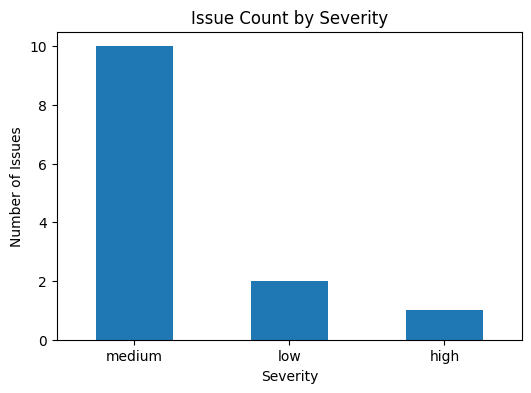

In [73]:
plot_severity_counts(issues_df)

In [74]:
def plot_issue_types(issues_df):
    if issues_df is None or len(issues_df) == 0:
        print("No issues to plot.")
        return

    check_counts = issues_df["check"].value_counts()

    plt.figure(figsize=(8, 4))
    check_counts.plot(kind="bar")
    plt.title("Issue Count by Type")
    plt.xlabel("Issue Type")
    plt.ylabel("Number of Issues")
    plt.xticks(rotation=45, ha="right")
    plt.show()

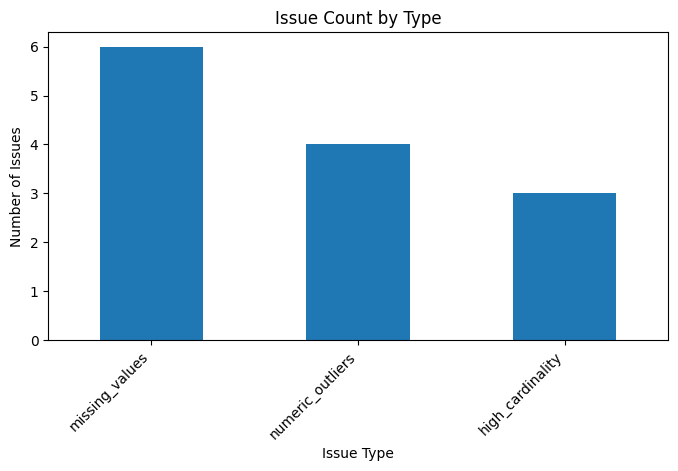

In [75]:
plot_issue_types(issues_df)

AI-READY DATA QUALITY REPORT

OVERALL SCORE
--------------------------------------------------
AI-Ready Score: 36/100
Grade: Poor
The dataset has serious quality issues. It is not recommended for AI/ML training without significant cleaning.

ISSUE SUMMARY
--------------------------------------------------
Total Issues: 13
High Severity: 1
Medium Severity: 10
Low Severity: 2

ISSUES BY TYPE
--------------------------------------------------
check
missing_values      6
numeric_outliers    4
high_cardinality    3
Name: count, dtype: int64

TOP ISSUES TO FIX
--------------------------------------------------
HIGH - high_cardinality - ride_id
Problem: Column 'ride_id' has 5733451 unique values, which is 100.00% of the dataset.
Recommendation: Check whether this column is an ID-like column. If yes, consider dropping it before modeling.

MEDIUM - missing_values - start_station_name
Problem: Column 'start_station_name' has 14.91% missing values.
Recommendation: Consider imputing this column or

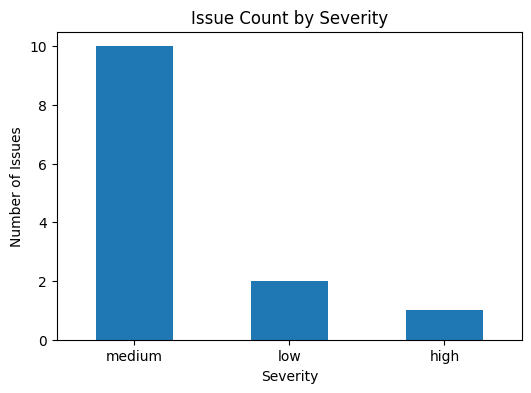

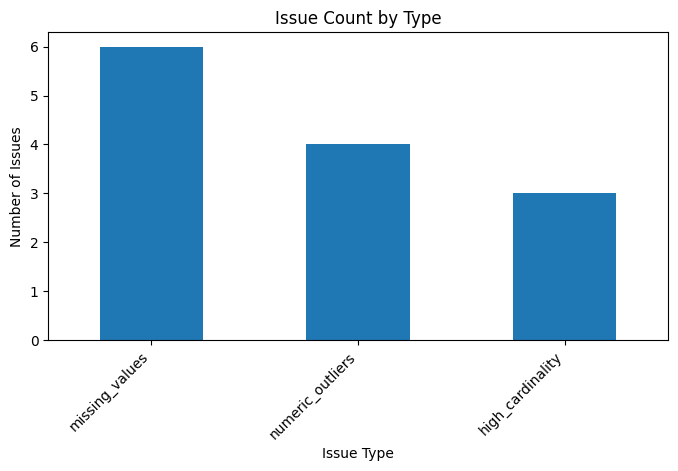

In [76]:
combined_df = load_csv_files(folder_path)

profile = create_data_profile(combined_df, target_col=target_col)

issues_df = run_quality_checks(combined_df, target_col=target_col)

score_result = compute_ai_ready_score(issues_df)

generate_text_report(score_result, issues_df)

plot_severity_counts(issues_df)

plot_issue_types(issues_df)

## Recommended next step

After this notebook runs cleanly, build a small report view:

- Overall readiness score
- Top 5 highest-severity issues
- Missing-value chart
- Target class distribution chart
- Column type summary

That will complete a strong Phase 1 + Phase 2 demo before moving into synthetic data generation.